In [125]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:, 0]      # Lead MLII
fs = record.fs                      # 360 Hz
r_peaks = annotation.sample
labels = annotation.symbol

In [126]:
import matplotlib.pyplot as plt

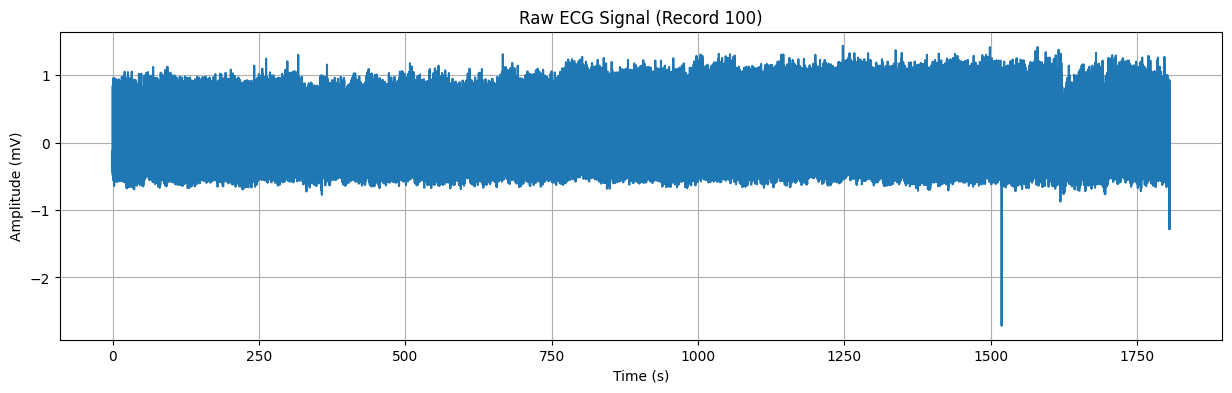

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis
t = np.arange(len(signal)) / fs

plt.figure(figsize=(15,4))
plt.plot(t, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Raw ECG Signal (Record 100)")
plt.grid(True)
plt.show()

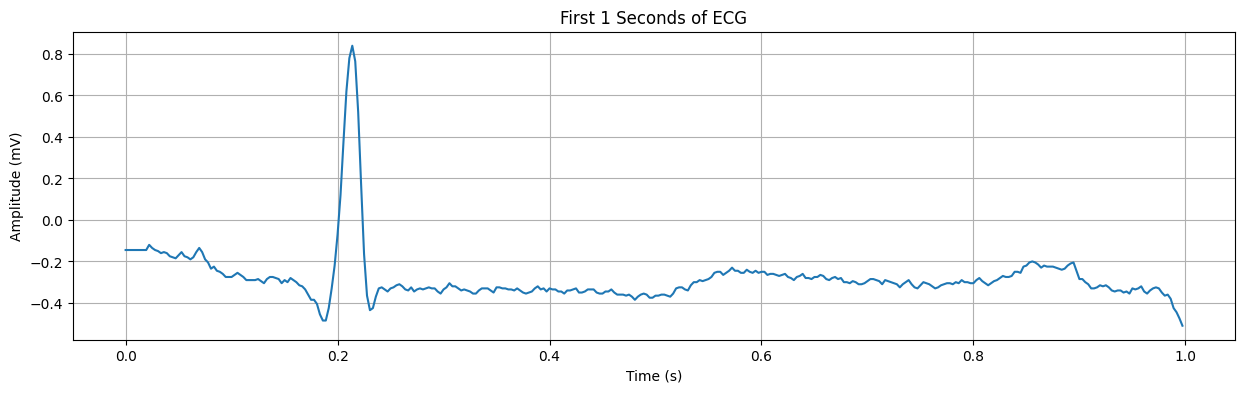

In [128]:
start = 0
duration = 1   # seconds

samples = duration * fs
t = np.arange(len(signal)) / fs
plt.figure(figsize=(15,4))
plt.plot(t[start:samples], signal[start:samples])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("First 1 Seconds of ECG")
plt.grid(True)
plt.show()

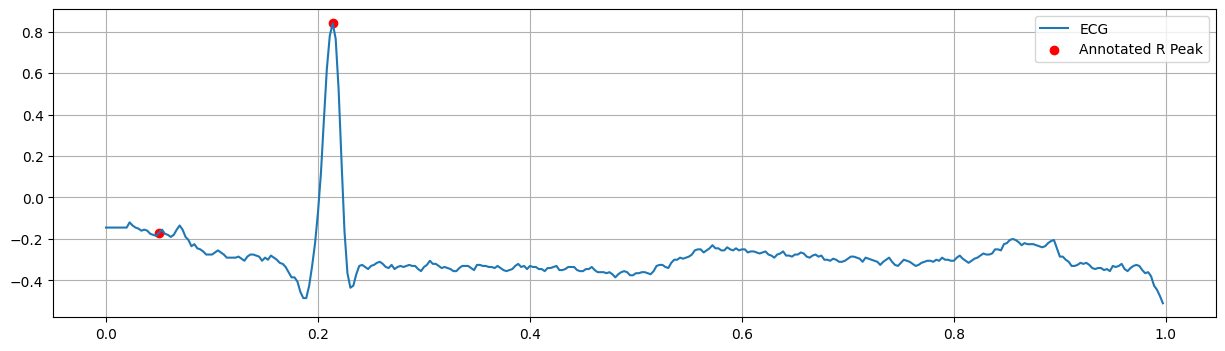

In [129]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], signal[:samples], label="ECG")

# R peaks in first 10 seconds
mask = r_peaks < samples


plt.scatter(
    r_peaks[mask] / fs,
    signal[r_peaks[mask]],
    color='red',
    label='Annotated R Peak'
)

plt.legend()
plt.grid(True)
plt.show()

In [130]:
from scipy.signal import butter, filtfilt

def bandpass(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    filtered = filtfilt(b, a, signal)

    return filtered

filtered = bandpass(signal)

C:\Users\aadit\AppData\Local\Temp\ipykernel_30340\791887304.py:7: RuntimeWarning: divide by zero encountered in divide
  f = 1/t


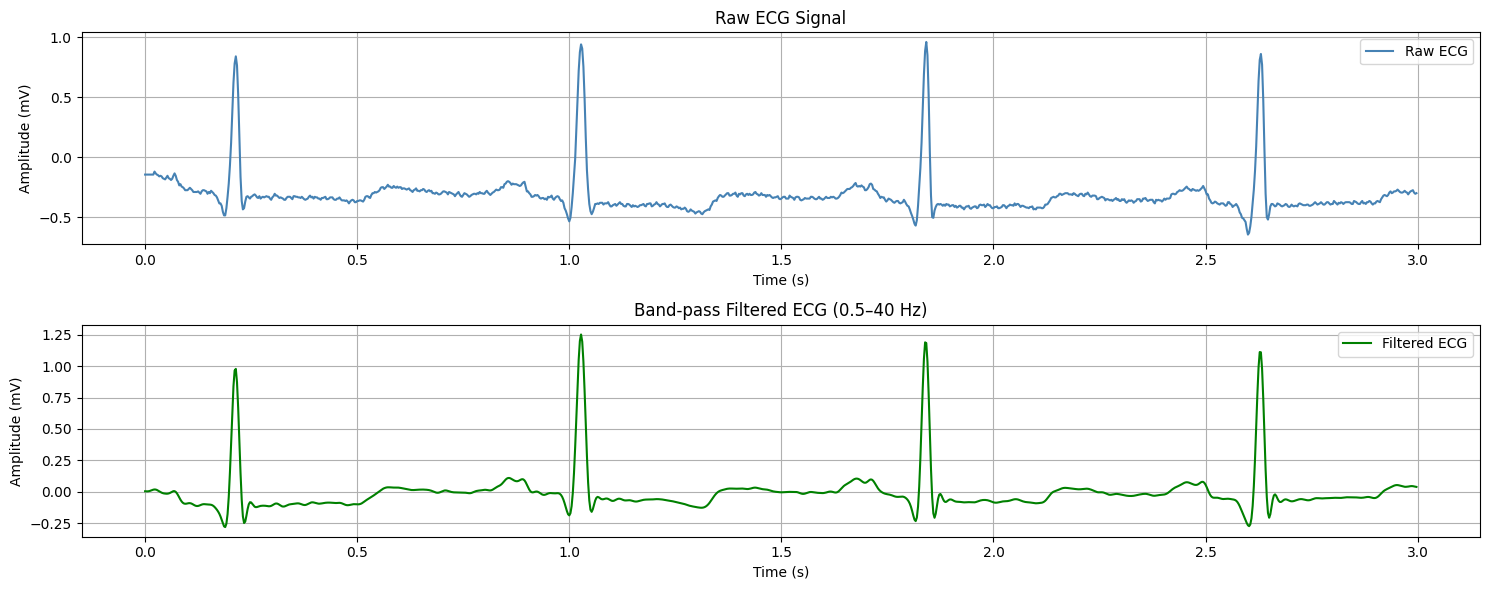

In [131]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis
t = np.arange(len(signal)) / fs

f = 1/t

duration = 3
samples = duration * fs

plt.figure(figsize=(15,6))

# ---------------- Raw ECG ----------------
plt.subplot(2,1,1)
plt.plot(t[:samples], signal[:samples], color='steelblue', label='Raw ECG')
plt.title("Raw ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()


plt.legend()

# ---------------- Filtered ECG ----------------
plt.subplot(2,1,2)
plt.plot(t[:samples], filtered[:samples], color='green', label='Filtered ECG')
plt.title("Band-pass Filtered ECG (0.5–40 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [132]:
import numpy as np

kernel = np.array([-1, -2, 0, 2, 1]) / 8.0

derivative = np.convolve(filtered, kernel, mode='same')

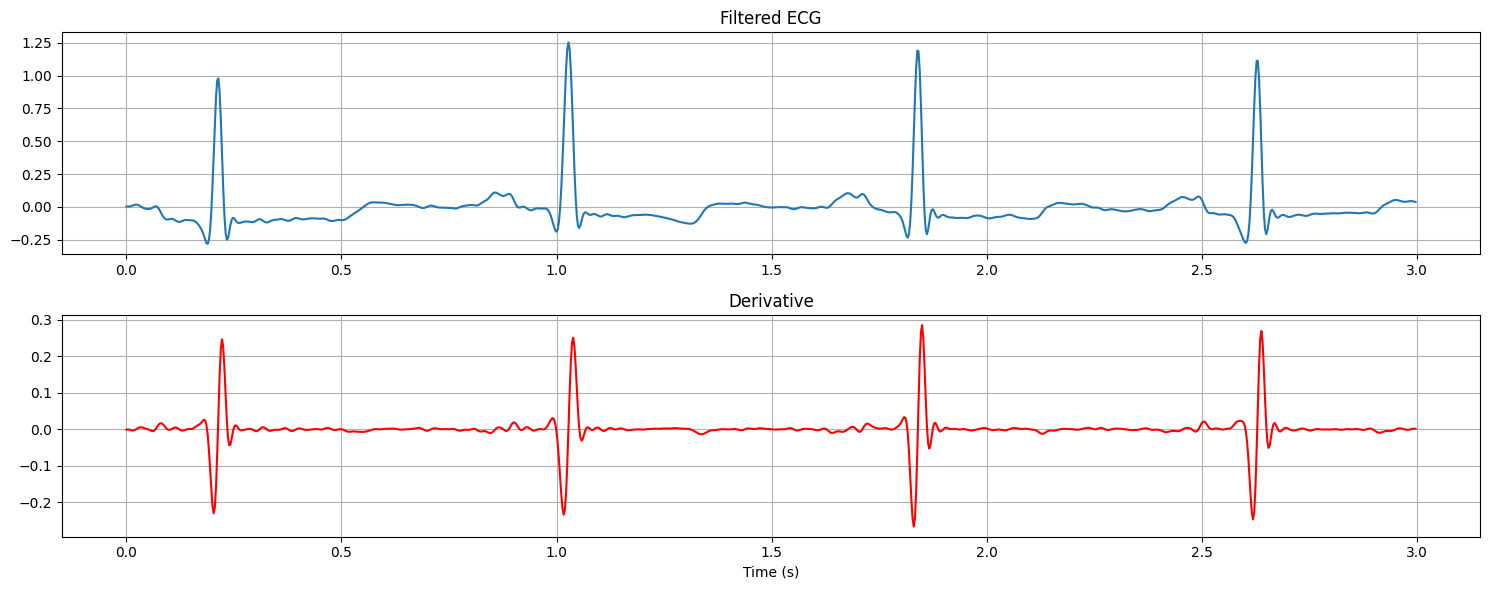

In [133]:
import matplotlib.pyplot as plt

duration = 3
samples = duration * fs
t = np.arange(len(filtered)) / fs

plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t[:samples], filtered[:samples])

plt.title("Filtered ECG")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t[:samples], derivative[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [134]:
squared = derivative**2 

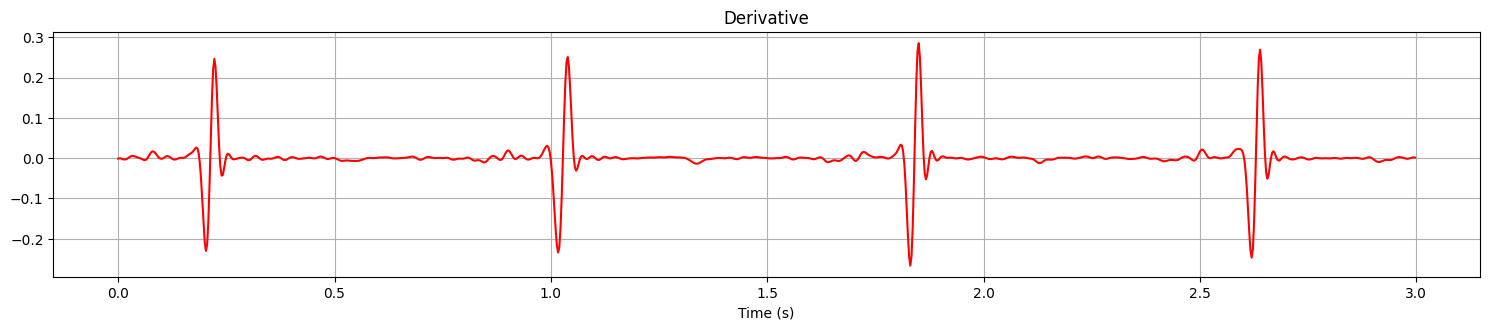

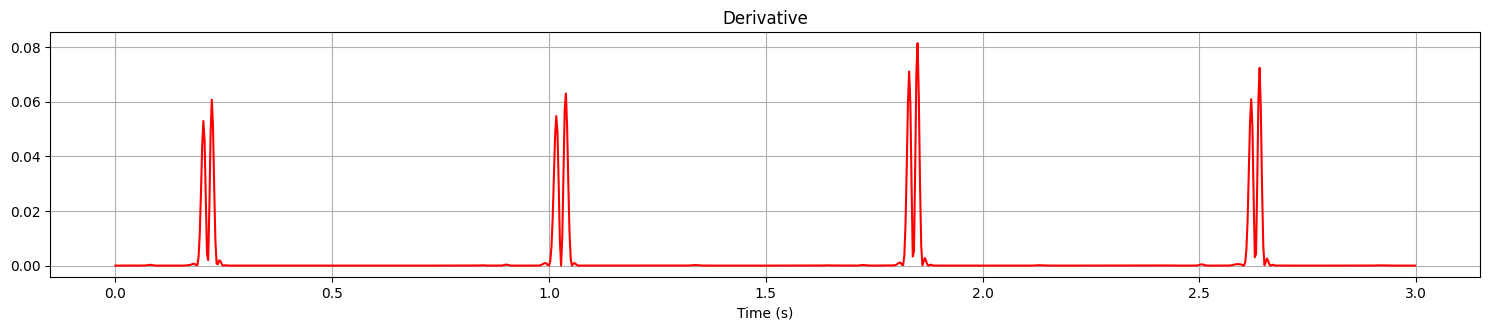

In [135]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t[:samples], derivative[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], squared[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [136]:
N = 54
mwi = np.zeros(len(squared))

for n in range(N - 1, len(squared)):
    window_sum = 0

    for i in range(N):
        window_sum += squared[n - i]

    mwi[n] = window_sum / N

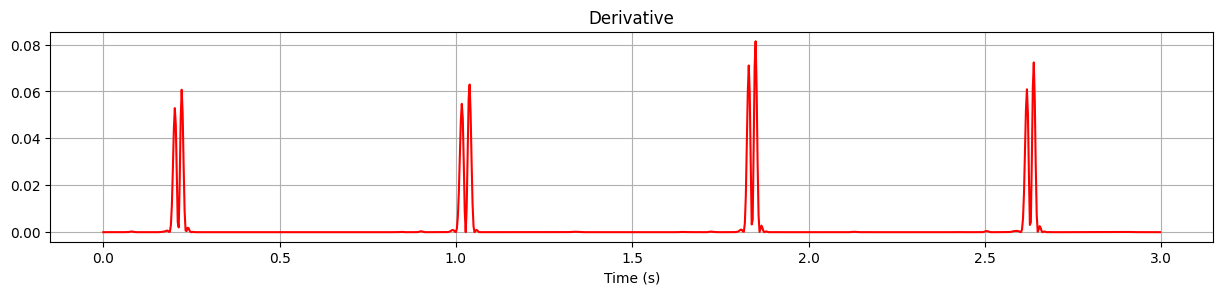

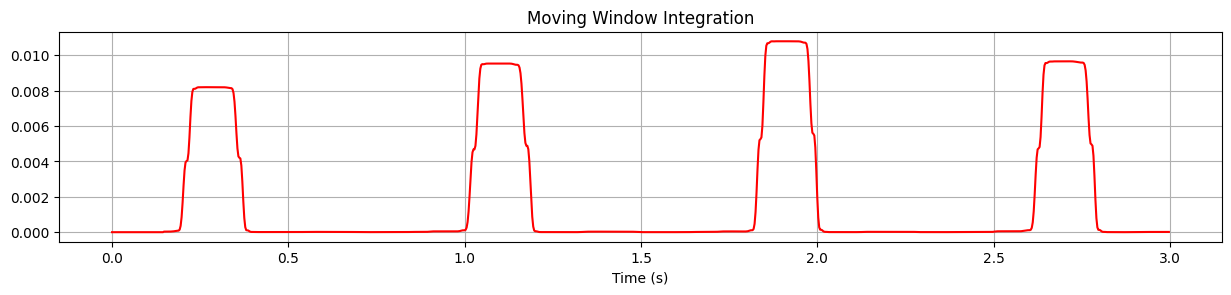

In [137]:

plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], squared[:samples], color='red')
plt.title("Derivative")
plt.xlabel("Time (s)")
plt.grid(True)


plt.figure(figsize=(15,6))
plt.subplot(2,1,2)
plt.plot(t[:samples], mwi[:samples], color='red')
plt.title("Moving Window Integration")
plt.xlabel("Time (s)")
plt.grid(True)

In [138]:
threshold = 0.4 * np.max(mwi)

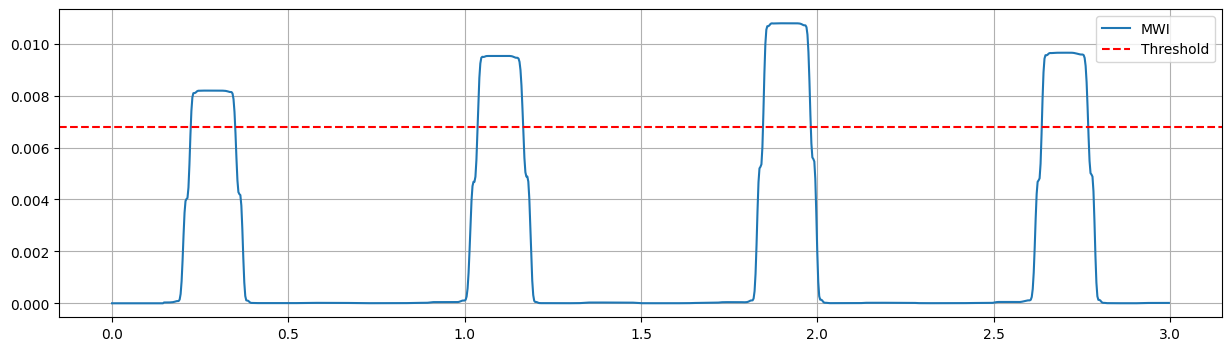

In [139]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples], label="MWI")
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')

plt.legend()
plt.grid(True)
plt.show()

In [140]:
peaks, _ = find_peaks(
    mwi,
    distance=int(0.2 * fs)
)

In [141]:
SPKI = 0
NPKI = 0
threshold = 0
detected = []

In [142]:
for p in peaks:

    amp = mwi[p]

    if amp > threshold:

        # Signal peak
        SPKI = 0.125 * amp + 0.875 * SPKI

        detected.append(p)

    else:

        # Noise peak
        NPKI = 0.125 * amp + 0.875 * NPKI

    threshold = NPKI + 0.25 * (SPKI - NPKI)

In [143]:
SPKI = 0
NPKI = 0
threshold = 0

detected = []
noise = []

threshold_history = []
spki_history = []
npki_history = []

for p in peaks:

    amp = mwi[p]

    if amp > threshold:

        # Signal Peak
        SPKI = 0.125 * amp + 0.875 * SPKI
        detected.append(p)

    else:

        # Noise Peak
        NPKI = 0.125 * amp + 0.875 * NPKI
        noise.append(p)

    threshold = NPKI + 0.25 * (SPKI - NPKI)

    threshold_history.append(threshold)
    spki_history.append(SPKI)
    npki_history.append(NPKI)

In [144]:
threshold_curve = np.zeros_like(mwi)

current_threshold = threshold

peak_set = set(peaks)

for i in range(len(mwi)):
    threshold_curve[i] = current_threshold

    if i in peak_set:
        # update SPKI/NPKI
        ...
        current_threshold = NPKI + 0.25*(SPKI-NPKI)

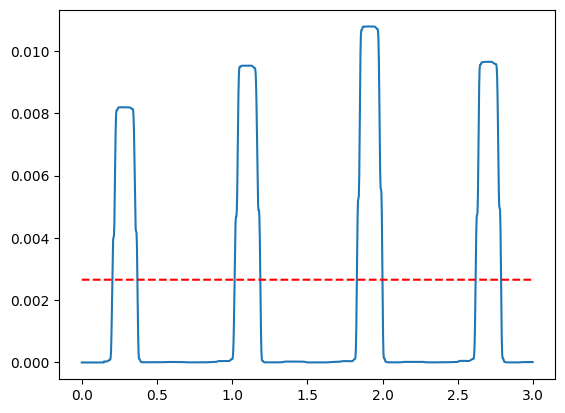

In [145]:
plt.plot(t[:samples], mwi[:samples], label='MWI')
plt.plot(t[:samples], threshold_curve[:samples], 'r--')

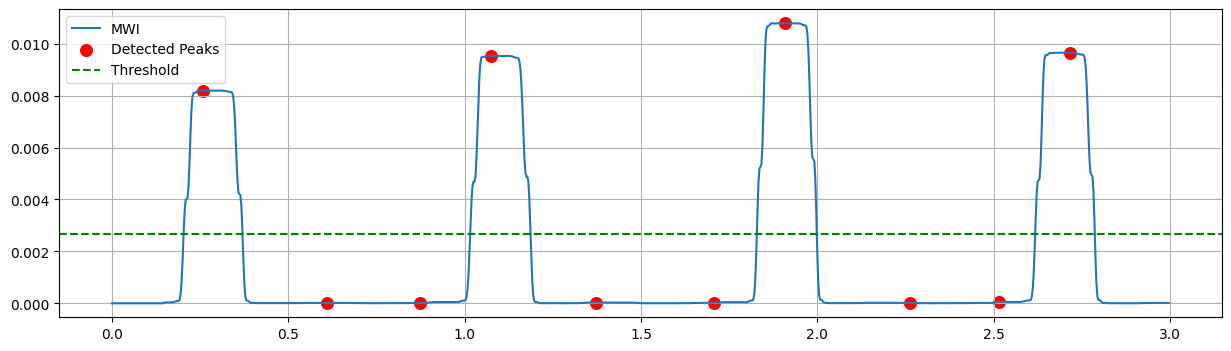

In [146]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples], label="MWI")

mask = peaks < samples

plt.scatter(
    peaks[mask]/fs,
    mwi[peaks[mask]],
    color='red',
    s=70,
    label="Detected Peaks"
)

plt.axhline(threshold, color='green', linestyle='--', label='Threshold')

plt.grid(True)
plt.legend()
plt.show()

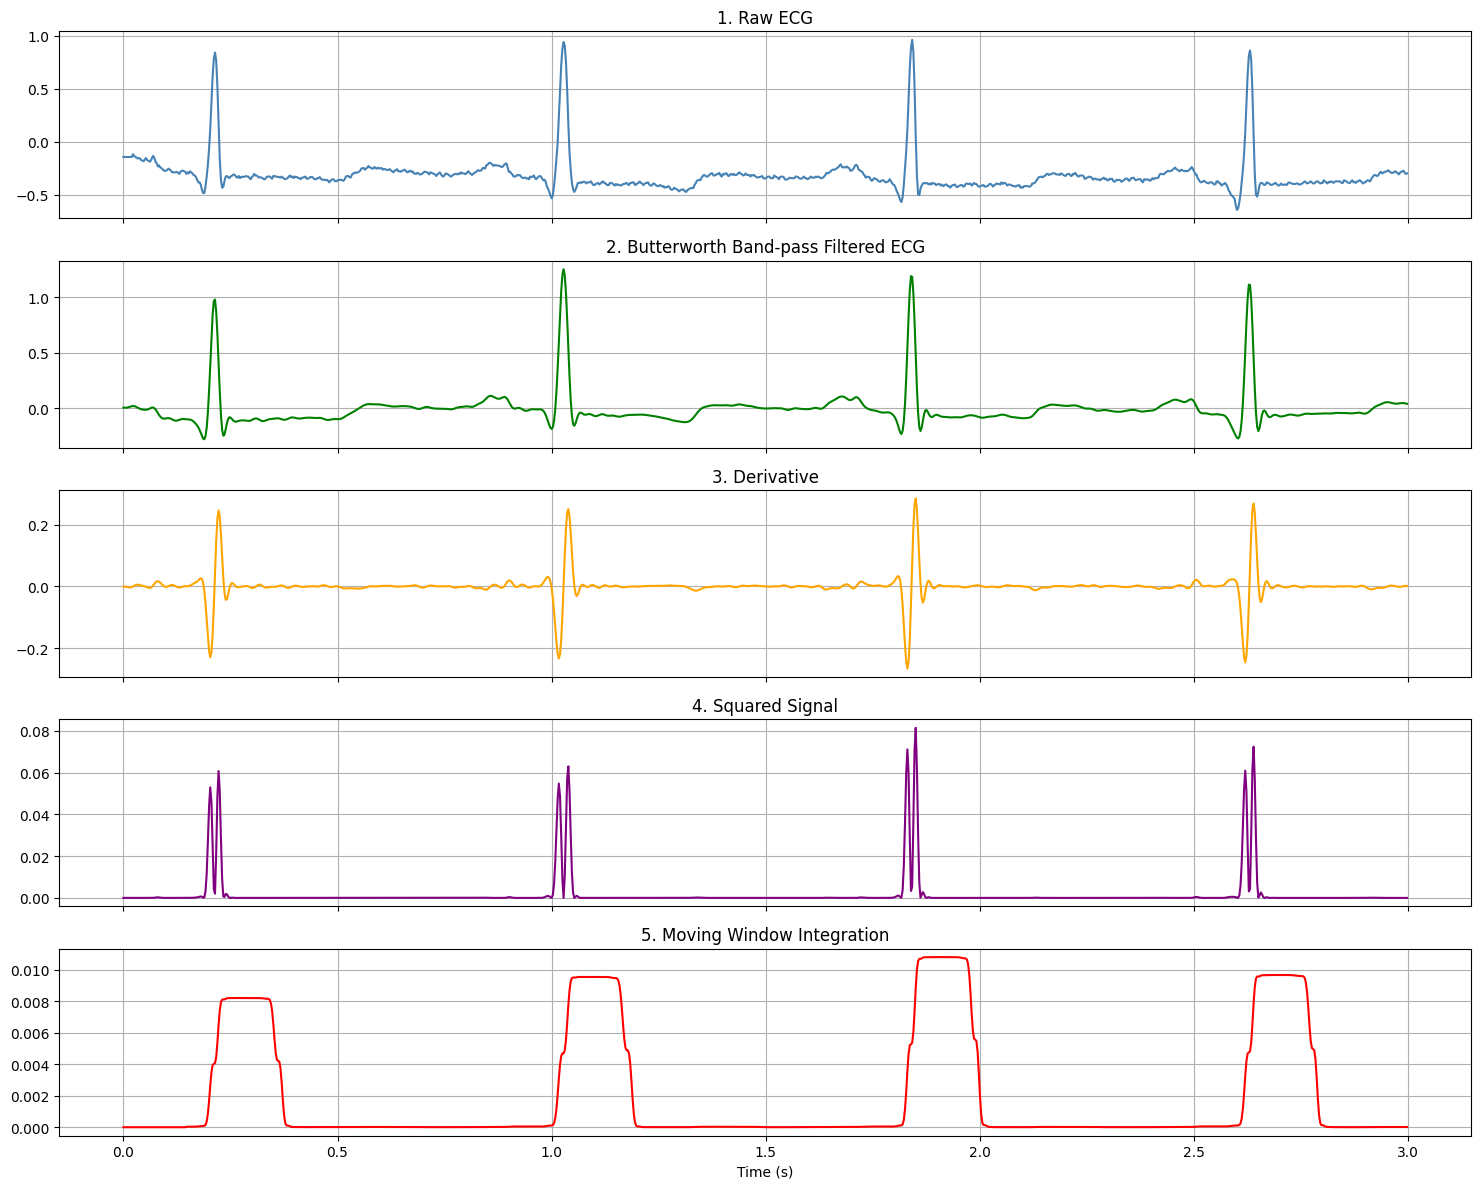

In [147]:
import matplotlib.pyplot as plt
import numpy as np

duration = 3
samples = int(duration * fs)

t = np.arange(samples) / fs

fig, ax = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

# 1. Raw ECG
ax[0].plot(t, signal[:samples], color='steelblue')
ax[0].set_title("1. Raw ECG")
ax[0].grid(True)

# 2. Butterworth Band-pass
ax[1].plot(t, filtered[:samples], color='green')
ax[1].set_title("2. Butterworth Band-pass Filtered ECG")
ax[1].grid(True)

# 3. Derivative
ax[2].plot(t, derivative[:samples], color='orange')
ax[2].set_title("3. Derivative")
ax[2].grid(True)

# 4. Squared
ax[3].plot(t, squared[:samples], color='purple')
ax[3].set_title("4. Squared Signal")
ax[3].grid(True)

# 5. Moving Window Integration
ax[4].plot(t, mwi[:samples], color='red')
ax[4].set_title("5. Moving Window Integration")
ax[4].set_xlabel("Time (s)")
ax[4].grid(True)

plt.tight_layout()
plt.show()

In [148]:
def find_local_maxima(signal):
    peaks = []

    for i in range(1, len(signal)-1):

        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            peaks.append(i)

    return np.array(peaks)

In [149]:
candidates = find_local_maxima(mwi)

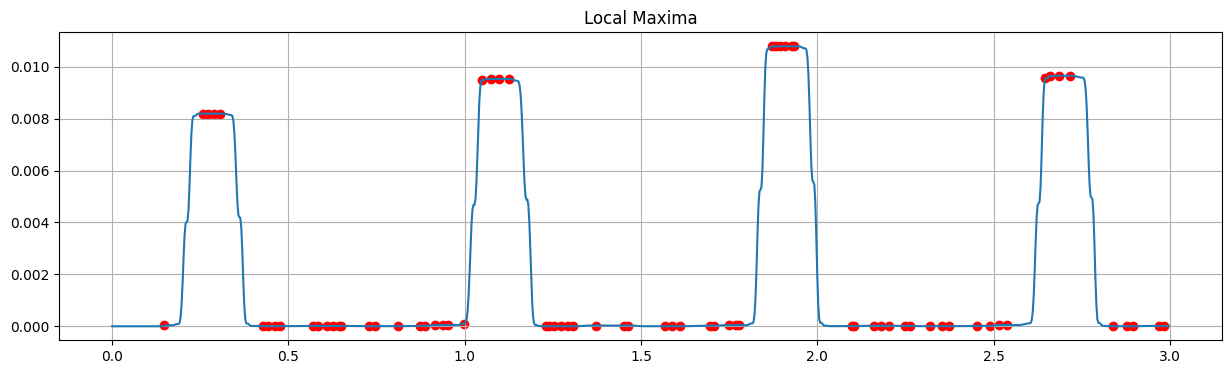

In [150]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples])

mask = candidates < samples

plt.scatter(
    candidates[mask]/fs,
    mwi[candidates[mask]],
    color='red'
)

plt.title("Local Maxima")
plt.grid(True)
plt.show()

In [151]:
def refractory_filter(signal, peaks, fs):

    min_distance = int(0.2 * fs)

    accepted = []

    accepted.append(peaks[0])

    for p in peaks[1:]:

        if p - accepted[-1] > min_distance:

            accepted.append(p)

        else:

            if signal[p] > signal[accepted[-1]]:
                accepted[-1] = p

    return np.array(accepted)

In [152]:
candidates = refractory_filter(
    mwi,
    candidates,
    fs
)

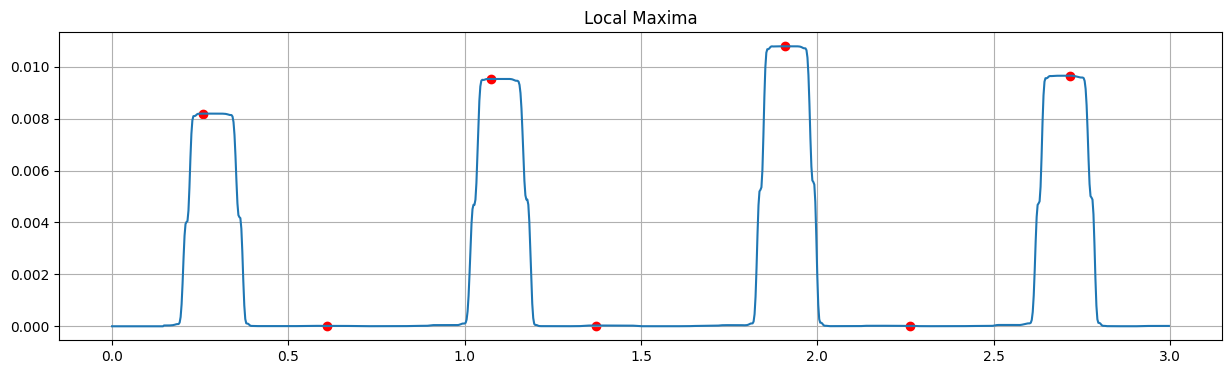

In [153]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples])

mask = candidates < samples

plt.scatter(
    candidates[mask]/fs,
    mwi[candidates[mask]],
    color='red'
)

plt.title("Local Maxima")
plt.grid(True)
plt.show()

In [154]:
import numpy as np

def find_local_maxima(signal):
    peaks = []

    for i in range(1, len(signal)-1):

        if signal[i] >= signal[i-1] and signal[i] >= signal[i+1]:

            if signal[i] > signal[i-1] or signal[i] > signal[i+1]:
                peaks.append(i)

    return np.array(peaks)

In [155]:
candidates = find_local_maxima(mwi)

print("Candidate Peaks:", len(candidates))

Candidate Peaks: 47507


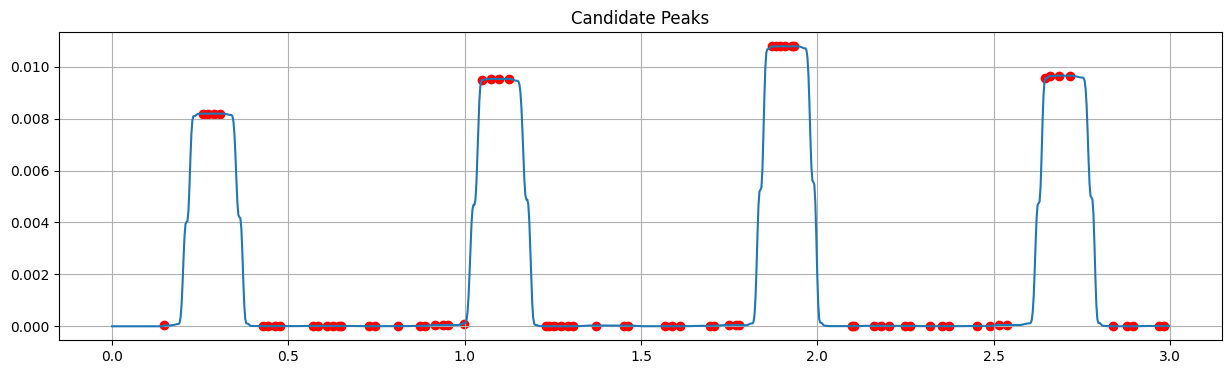

In [156]:
duration = 3
samples = duration * fs

plt.figure(figsize=(15,4))

plt.plot(t[:samples], mwi[:samples])

mask = candidates < samples

plt.scatter(
    candidates[mask]/fs,
    mwi[candidates[mask]],
    color='red'
)

plt.title("Candidate Peaks")
plt.grid(True)
plt.show()

In [157]:
def refractory_filter(signal, peaks, fs):

    min_distance = int(0.2*fs)

    accepted=[]

    accepted.append(peaks[0])

    for p in peaks[1:]:

        if p-accepted[-1] > min_distance:

            accepted.append(p)

        else:

            if signal[p] > signal[accepted[-1]]:
                accepted[-1]=p

    return np.array(accepted)

In [158]:
candidates = refractory_filter(
    mwi,
    candidates,
    fs
)

print("After Refractory:",len(candidates))

After Refractory: 4281


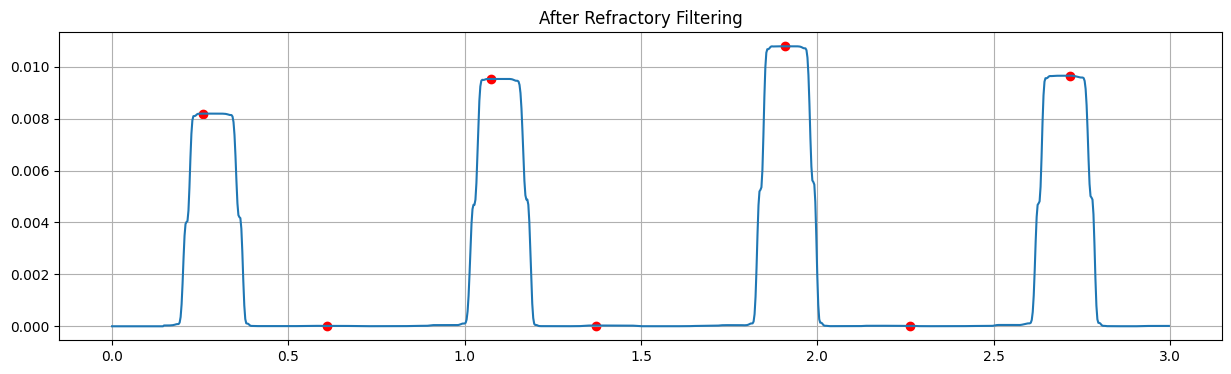

In [159]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples],mwi[:samples])

mask=candidates<samples

plt.scatter(
    candidates[mask]/fs,
    mwi[candidates[mask]],
    color='red'
)

plt.title("After Refractory Filtering")
plt.grid(True)
plt.show()

In [160]:
learning=int(2*fs)

SPKI=0.125*np.max(mwi[:learning])

NPKI=0.125*np.mean(mwi[:learning])

threshold=NPKI+0.25*(SPKI-NPKI)

In [161]:
qrs=[]

noise=[]

threshold_history=[]

for p in candidates:

    amp=mwi[p]

    if amp>threshold:

        qrs.append(p)

        SPKI=0.125*amp+0.875*SPKI

    else:

        noise.append(p)

        NPKI=0.125*amp+0.875*NPKI

    threshold=NPKI+0.25*(SPKI-NPKI)

    threshold_history.append(threshold)

In [162]:
print("QRS:",len(qrs))
print("Noise:",len(noise))

QRS: 2273
Noise: 2008


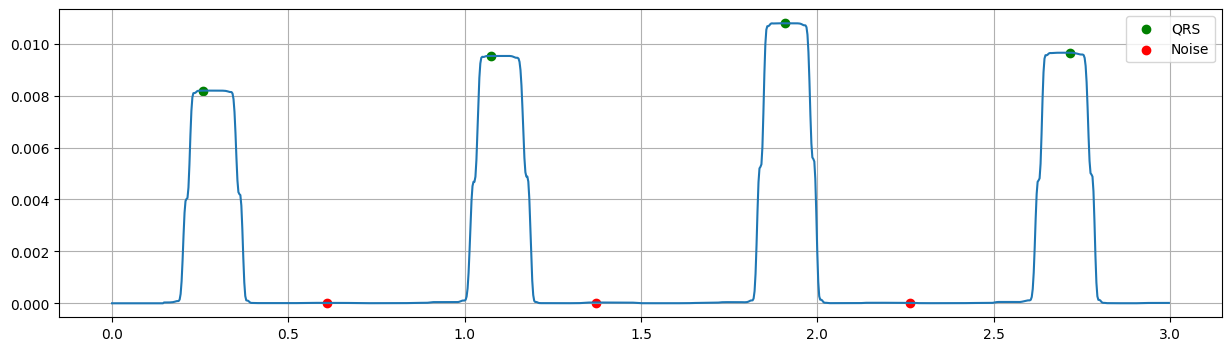

In [163]:
plt.figure(figsize=(15,4))

plt.plot(t[:samples],mwi[:samples])

mask=np.array(qrs)<samples

plt.scatter(
    np.array(qrs)[mask]/fs,
    mwi[np.array(qrs)[mask]],
    color='green',
    label='QRS'
)

mask=np.array(noise)<samples

plt.scatter(
    np.array(noise)[mask]/fs,
    mwi[np.array(noise)[mask]],
    color='red',
    label='Noise'
)

plt.legend()
plt.grid(True)
plt.show()

In [164]:
def search_back(filtered,qrs,fs):

    search=int(0.1*fs)

    r_detected=[]

    for p in qrs:

        start=max(0,p-search)

        end=p

        r=start+np.argmax(filtered[start:end])

        r_detected.append(r)

    return np.array(r_detected)

In [165]:
r_detected=search_back(
    filtered,
    np.array(qrs),
    fs
)

print("Detected R Peaks:",len(r_detected))

Detected R Peaks: 2273


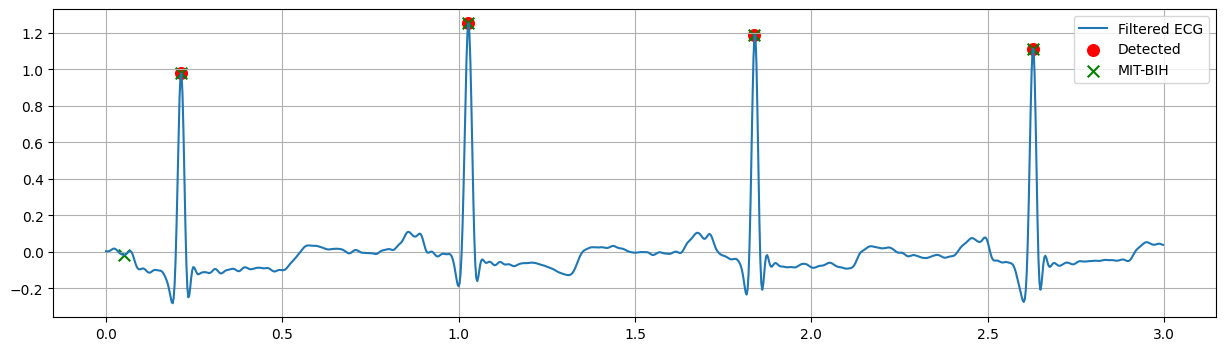

In [166]:
plt.figure(figsize=(15,4))

plt.plot(
    t[:samples],
    filtered[:samples],
    label="Filtered ECG"
)

mask=r_detected<samples

plt.scatter(
    r_detected[mask]/fs,
    filtered[r_detected[mask]],
    color='red',
    s=70,
    label='Detected'
)

mask=r_peaks<samples

plt.scatter(
    r_peaks[mask]/fs,
    filtered[r_peaks[mask]],
    color='green',
    marker='x',
    s=70,
    label='MIT-BIH'
)

plt.legend()
plt.grid(True)
plt.show()

In [167]:
for i in range(10):
    print(annotation.sample[i], annotation.symbol[i])

18 +
77 N
370 N
662 N
946 N
1231 N
1515 N
1809 N
2044 A
2402 N


In [168]:
beat_symbols = [
    'N','L','R','B','A','a','J','S',
    'V','r','F','e','j','n','E','/',
    'f','Q','?'
]

mask = np.isin(annotation.symbol, beat_symbols)

r_peaks = annotation.sample[mask]
labels = np.array(annotation.symbol)[mask]

In [169]:
print(annotation.sample[:10])
print(annotation.symbol[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [170]:
for s, sym in zip(annotation.sample[:10], annotation.symbol[:10]):
    print(s, sym)

18 +
77 N
370 N
662 N
946 N
1231 N
1515 N
1809 N
2044 A
2402 N


In [171]:
beat_symbols = [
    'N','L','R','B','A','a','J','S',
    'V','r','F','e','j','n','E','/',
    'f','Q','?'
]

mask = np.isin(annotation.symbol, beat_symbols)

r_peaks = annotation.sample[mask]
labels = np.array(annotation.symbol)[mask]

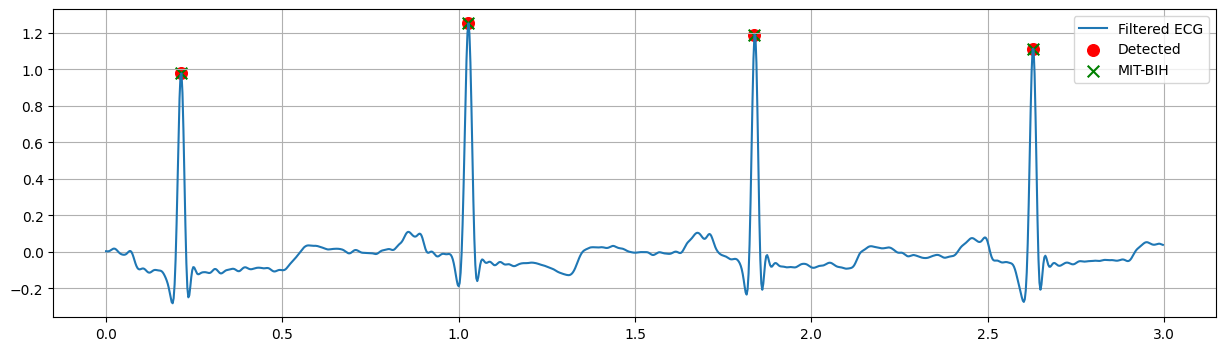

In [172]:
plt.figure(figsize=(15,4))

plt.plot(
    t[:samples],
    filtered[:samples],
    label="Filtered ECG"
)

mask=r_detected<samples

plt.scatter(
    r_detected[mask]/fs,
    filtered[r_detected[mask]],
    color='red',
    s=70,
    label='Detected'
)

mask=r_peaks<samples

plt.scatter(
    r_peaks[mask]/fs,
    filtered[r_peaks[mask]],
    color='green',
    marker='x',
    s=70,
    label='MIT-BIH'
)

plt.legend()
plt.grid(True)
plt.show()

In [173]:
records = [
    '100',
    '101',
    '102',
    '103',
    '105',
    '106',
    '107',
    '109'
]

In [181]:
def match_peaks_to_annotations(r_detected, r_peaks, labels, fs, tolerance_ms=150):
    tolerance_samples = int(tolerance_ms * fs / 1000)

    matched_peaks = []
    matched_labels = []
    n_unmatched = 0

    r_peaks_arr = np.asarray(r_peaks)

    for peak in r_detected:
        distances = np.abs(r_peaks_arr - peak)
        nearest_idx = np.argmin(distances)
        nearest_dist = distances[nearest_idx]

        if nearest_dist <= tolerance_samples:
            matched_peaks.append(peak)
            matched_labels.append(labels[nearest_idx])
        else:
            n_unmatched += 1

    return np.array(matched_peaks), np.array(matched_labels), n_unmatched


matched_peaks, matched_labels, n_unmatched = match_peaks_to_annotations(
    r_detected, r_peaks, labels, fs, tolerance_ms=150
)
print(f"Matched: {len(matched_peaks)}  |  Unmatched (false positives): {n_unmatched}")

Matched: 2273  |  Unmatched (false positives): 0


In [182]:
def segment_heartbeats(filtered, peaks, fs, pre_sec=0.25, post_sec=0.45):
    pre_samples = int(pre_sec * fs)
    post_samples = int(post_sec * fs)

    segments = []
    valid_peaks = []

    for peak in peaks:
        lo = peak - pre_samples
        hi = peak + post_samples
        if lo < 0 or hi > len(filtered):
            continue
        segments.append(filtered[lo:hi])
        valid_peaks.append(peak)

    return np.array(segments), np.array(valid_peaks)

In [183]:
def extract_features(segment, peak, prev_peak, next_peak, fs):
    features = {}

    features['max_amp'] = np.max(segment)
    features['min_amp'] = np.min(segment)
    features['mean_amp'] = np.mean(segment)
    features['std_amp'] = np.std(segment)
    features['range_amp'] = features['max_amp'] - features['min_amp']

    half_max = features['max_amp'] / 2
    above_half = np.where(segment > half_max)[0]
    features['qrs_width'] = (above_half[-1] - above_half[0]) if len(above_half) > 0 else 0

    features['rr_prev'] = (peak - prev_peak) / fs if prev_peak is not None else np.nan
    features['rr_next'] = (next_peak - peak) / fs if next_peak is not None else np.nan

    return features

In [184]:
def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(peak_to_label[peak])

    return X, y, segments

In [185]:
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue  # not a valid beat symbol (e.g. rhythm/quality annotation) -> skip

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next

In [186]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X1, y1, _ = build_feature_dataset(filtered, r_peaks, labels, fs)

df1 = pd.DataFrame(X1)
df1['label'] = y1
df1 = df1.dropna()

print("Pipeline 1 class distribution:")
print(df1['label'].value_counts())

X1_train, X1_test, y1_train, y1_test = train_test_split(
    df1.drop(columns='label'), df1['label'], test_size=0.2,
    random_state=42, stratify=df1['label']
)

clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)

print("=== Pipeline 1: MIT-BIH annotation peaks ===")
print(classification_report(y1_test, y1_pred))

TypeError: cannot unpack non-iterable NoneType object

In [187]:
result = match_peaks_to_annotations(r_detected, r_peaks, labels, fs, tolerance_ms=150)
print(result)

(array([    77,    370,    662, ..., 649484, 649733, 649989], shape=(2273,)), array(['N', 'N', 'N', ..., 'N', 'N', 'N'], shape=(2273,), dtype='<U1'), 0)


In [188]:
result = build_feature_dataset(filtered, r_peaks, labels, fs)
print(result)

None


In [189]:
import inspect
print(inspect.getsource(build_feature_dataset))

def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue  # not a valid beat symbol (e.g. rhythm/quality annotation) -> skip

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next



In [190]:
import inspect

print("=== Source Python is currently using ===")
print(inspect.getsource(build_feature_dataset))

print("\n=== Direct call test ===")
result = build_feature_dataset(filtered, r_peaks, labels, fs)
print("Type of result:", type(result))
print("Result:", result)

=== Source Python is currently using ===
def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue  # not a valid beat symbol (e.g. rhythm/quality annotation) -> skip

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next


=== Direct call test ===
Type of result: <class 'NoneType'>
Result: None


In [191]:
def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)
    peak_to_label = dict(zip(peaks, labels_for_peaks))
    X = []
    y = []
    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)
        if aami_label is None:
            continue
        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(aami_label)

    return X, y, segments          # <-- this line is missing in your version

In [192]:
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(aami_label)

    return X, y, segments

In [193]:
print(inspect.getsource(build_feature_dataset))

def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(aami_label)

    return X, y, segments



In [196]:
import wfdb

def build_dataset_across_records(records, data_path, aami_map, fs_expected=None,
                                   pre_sec=0.25, post_sec=0.45, tolerance_ms=150):
    """
    Loops through each MIT-BIH record, runs your existing DSP pipeline
    (unchanged), matches detected peaks to annotations, and builds two
    feature datasets (annotation-based and detected-based), each tagged
    with which record every row came from.
    """
    all_X1, all_y1, all_rec1 = [], [], []   # Pipeline 1: annotation peaks
    all_X2, all_y2, all_rec2 = [], [], []   # Pipeline 2: detected peaks

    for rec_name in records:
        record = wfdb.rdrecord(f"{data_path}/{rec_name}")
        annotation = wfdb.rdann(f"{data_path}/{rec_name}", 'atr')

        signal = record.p_signal[:, 0]
        fs = record.fs
        r_peaks_rec = annotation.sample
        labels_rec = annotation.symbol

        # --- your existing unchanged DSP pipeline goes here ---
        # filtered = butterworth_bandpass(signal, fs)
        # derivative = ...
        # squared = ...
        # mwi = ...
        # candidates = find_local_maxima(mwi)
        # candidates = refractory_filter(mwi, candidates, fs)
        # qrs_in_mwi = pan_tompkins_adaptive_threshold(mwi, candidates, fs)
        # r_detected_rec = backproject_to_filtered_signal(filtered, qrs_in_mwi, fs)
        # -------------------------------------------------------

        # Pipeline 1: ground-truth annotation peaks
        X1, y1, _ = build_feature_dataset(filtered, r_peaks_rec, labels_rec, fs, pre_sec, post_sec)
        all_X1.extend(X1)
        all_y1.extend(y1)
        all_rec1.extend([rec_name] * len(X1))

        # Pipeline 2: detected peaks, matched to annotations
        matched_peaks, matched_labels, n_unmatched = match_peaks_to_annotations(
            r_detected_rec, r_peaks_rec, labels_rec, fs, tolerance_ms
        )
        X2, y2, _ = build_feature_dataset(filtered, matched_peaks, matched_labels, fs, pre_sec, post_sec)
        all_X2.extend(X2)
        all_y2.extend(y2)
        all_rec2.extend([rec_name] * len(X2))

        print(f"Record {rec_name}: {len(X1)} annotated beats, {len(X2)} matched detected beats "
              f"({n_unmatched} false positives)")

    return all_X1, all_y1, all_rec1, all_X2, all_y2, all_rec2

In [198]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\aadit\Documents\Human-Activity-Recognition-using-Smartphone-Sensors
['.git', '.gitignore', 'basics', 'mit-bih-arrhythmia-database-1.0.0', 'model.ipynb', 'testing.ipynb']


In [199]:
print(os.listdir("mit-bih-arrhythmia-database-1.0.0"))

['mit-bih-arrhythmia-database-1.0.0']


In [200]:
data_path = "mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0"

In [201]:
import os
print(os.listdir(data_path))

['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat', '103.hea', '103.xws', '104.atr', '104.dat', '104.hea', '104.xws', '105.atr', '105.dat', '105.hea', '105.xws', '106.atr', '106.dat', '106.hea', '106.xws', '107.atr', '107.dat', '107.hea', '107.xws', '108.atr', '108.at_', '108.dat', '108.hea', '108.xws', '109.atr', '109.dat', '109.hea', '109.xws', '111.atr', '111.dat', '111.hea', '111.xws', '112.atr', '112.dat', '112.hea', '112.xws', '113.atr', '113.dat', '113.hea', '113.xws', '114.atr', '114.dat', '114.hea', '114.xws', '115.atr', '115.dat', '115.hea', '115.xws', '116.atr', '116.dat', '116.hea', '116.xws', '117.atr', '117.at_', '117.dat', '117.hea', '117.xws', '118.atr', '118.dat', '118.hea', '118.xws', '119.atr', '119.at_', '119.dat', '119.hea', '119.xws', '121.atr', '121.dat', '121.hea', '121.xws', '122.atr', '122.dat', '122.hea', '122.xws', '123.atr', '123.dat', '123.he

In [203]:
import wfdb

def build_dataset_across_records(records, data_path, aami_map, fs_expected=None,
                                   pre_sec=0.25, post_sec=0.45, tolerance_ms=150):
    all_X1, all_y1, all_rec1 = [], [], []   # Pipeline 1: annotation peaks
    all_X2, all_y2, all_rec2 = [], [], []   # Pipeline 2: detected peaks

    for rec_name in records:
        record = wfdb.rdrecord(f"{data_path}/{rec_name}")
        annotation = wfdb.rdann(f"{data_path}/{rec_name}", 'atr')

        signal = record.p_signal[:, 0]
        fs = record.fs
        r_peaks_rec = annotation.sample
        labels_rec = annotation.symbol

        # --- your existing DSP pipeline, called per record ---
        filtered = butterworth_bandpass(signal, fs)          # <-- your existing function
        derivative = compute_derivative(filtered)             # <-- your existing function
        squared = derivative ** 2
        mwi = moving_window_integration(squared, fs)          # <-- your existing function

        candidates = find_local_maxima(mwi)
        candidates = refractory_filter(mwi, candidates, fs)
        qrs_in_mwi = pan_tompkins_adaptive_threshold(mwi, candidates, fs)
        r_detected_rec = backproject_to_filtered_signal(filtered, qrs_in_mwi, fs)
        # ----------------------------------------

In [204]:
import pandas as pd

data_path = "mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0"

X1, y1, rec1, X2, y2, rec2 = build_dataset_across_records(
    records, data_path, aami_map
)

df1 = pd.DataFrame(X1)
df1['label'] = y1
df1['record'] = rec1
df1 = df1.dropna()

df2 = pd.DataFrame(X2)
df2['label'] = y2
df2['record'] = rec2
df2 = df2.dropna()

print("Pipeline 1 (annotations) class distribution:")
print(df1['label'].value_counts())
print("\nPipeline 2 (detected) class distribution:")
print(df2['label'].value_counts())

NameError: name 'butterworth_bandpass' is not defined

In [205]:
peaks = []
above = mwi > threshold

i = 0
n_samples = len(mwi)

while i < n_samples:
    if above[i]:
        start = i
        while i < n_samples and above[i]:
            i += 1
        end = i
        # take the mwi local maximum within this above-threshold segment
        local_max_idx = start + np.argmax(mwi[start:end])
        peaks.append(local_max_idx)
    else:
        i += 1

peaks = np.array(peaks)

In [206]:
import numpy as np
from scipy.signal import butter, filtfilt

def bandpass(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


def process_record(signal, fs):
    # --- Bandpass filter ---
    filtered = bandpass(signal, fs=fs)

    # --- Derivative ---
    kernel = np.array([-1, -2, 0, 2, 1]) / 8.0
    derivative = np.convolve(filtered, kernel, mode='same')

    # --- Squaring ---
    squared = derivative ** 2

    # --- Moving Window Integration ---
    N = 54
    mwi = np.zeros(len(squared))
    for n in range(N - 1, len(squared)):
        window_sum = 0
        for i in range(N):
            window_sum += squared[n - i]
        mwi[n] = window_sum / N

    # --- Threshold ---
    threshold = 0.4 * np.max(mwi)

    # --- Peak detection (the missing step, added above) ---
    peaks = []
    above = mwi > threshold
    i = 0
    n_samples = len(mwi)
    while i < n_samples:
        if above[i]:
            start = i
            while i < n_samples and above[i]:
                i += 1
            end = i
            local_max_idx = start + np.argmax(mwi[start:end])
            peaks.append(local_max_idx)
        else:
            i += 1
    peaks = np.array(peaks)

    # --- Backproject to filtered ECG for true R-peak ---
    search = int(0.15 * fs / 2)
    r_detected = []
    for p in peaks:
        start = max(0, p - search)
        end = min(len(filtered), p + search)
        r = start + np.argmax(filtered[start:end])
        r_detected.append(r)
    r_detected = np.array(r_detected)

    return filtered, r_detected

In [207]:
filtered, r_detected_rec = process_record(signal, fs)

In [208]:
import wfdb

def build_dataset_across_records(records, aami_map, pre_sec=0.25, post_sec=0.45, tolerance_ms=150):
    all_X1, all_y1, all_rec1 = [], [], []   # Pipeline 1: annotation peaks
    all_X2, all_y2, all_rec2 = [], [], []   # Pipeline 2: detected peaks

    for rec_name in records:
        record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        annotation = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

        signal = record.p_signal[:, 0]
        fs = record.fs
        r_peaks_rec = annotation.sample
        labels_rec = annotation.symbol

        filtered, r_detected_rec = process_record(signal, fs)

        # Pipeline 1: ground-truth annotation peaks
        X1, y1, _ = build_feature_dataset(filtered, r_peaks_rec, labels_rec, fs, pre_sec, post_sec)
        all_X1.extend(X1)
        all_y1.extend(y1)
        all_rec1.extend([rec_name] * len(X1))

        # Pipeline 2: detected peaks, matched to annotations
        matched_peaks, matched_labels, n_unmatched = match_peaks_to_annotations(
            r_detected_rec, r_peaks_rec, labels_rec, fs, tolerance_ms
        )
        X2, y2, _ = build_feature_dataset(filtered, matched_peaks, matched_labels, fs, pre_sec, post_sec)
        all_X2.extend(X2)
        all_y2.extend(y2)
        all_rec2.extend([rec_name] * len(X2))

        print(f"Record {rec_name}: {len(X1)} annotated beats, {len(X2)} matched detected beats "
              f"({n_unmatched} false positives)")

    return all_X1, all_y1, all_rec1, all_X2, all_y2, all_rec2

In [209]:
import pandas as pd

X1, y1, rec1, X2, y2, rec2 = build_dataset_across_records(records, aami_map)

df1 = pd.DataFrame(X1)
df1['label'] = y1
df1['record'] = rec1
df1 = df1.dropna()

df2 = pd.DataFrame(X2)
df2['label'] = y2
df2['record'] = rec2
df2 = df2.dropna()

print("Pipeline 1 (annotations) class distribution:")
print(df1['label'].value_counts())
print("\nPipeline 2 (detected) class distribution:")
print(df2['label'].value_counts())

Record 100: 2271 annotated beats, 2267 matched detected beats (2 false positives)
Record 101: 1864 annotated beats, 1542 matched detected beats (1 false positives)
Record 102: 2186 annotated beats, 2073 matched detected beats (2 false positives)
Record 103: 2083 annotated beats, 2032 matched detected beats (17 false positives)
Record 105: 2572 annotated beats, 1 matched detected beats (1 false positives)
Record 106: 2027 annotated beats, 982 matched detected beats (8 false positives)
Record 107: 2137 annotated beats, 1042 matched detected beats (1001 false positives)
Record 109: 2531 annotated beats, 302 matched detected beats (3 false positives)
Pipeline 1 (annotations) class distribution:
label
N    12789
Q     4164
V      663
S       38
F        2
Name: count, dtype: int64

Pipeline 2 (detected) class distribution:
label
N    7016
Q    3107
V      65
S      38
Name: count, dtype: int64


In [210]:
for r in records:
    print(r, df1[df1['record'] == r]['label'].value_counts().to_dict())

100 {'N': 2235, 'S': 33, 'V': 1}
101 {'N': 1857, 'S': 3, 'Q': 2}
102 {'Q': 2081, 'N': 99, 'V': 4}
103 {'N': 2079, 'S': 2}
105 {'N': 2524, 'V': 41, 'Q': 5}
106 {'N': 1506, 'V': 520}
107 {'Q': 2076, 'V': 59}
109 {'N': 2489, 'V': 38, 'F': 2}


In [211]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

def record_level_split(df, test_records):
    train_df = df[~df['record'].isin(test_records)]
    test_df = df[df['record'].isin(test_records)]
    return train_df, test_df

test_records = ['107', '109']   # adjust based on Cell C output

train_df1, test_df1 = record_level_split(df1, test_records)

X1_train = train_df1.drop(columns=['label', 'record'])
y1_train = train_df1['label']
X1_test = test_df1.drop(columns=['label', 'record'])
y1_test = test_df1['label']

clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)

print("=== Pipeline 1: MIT-BIH annotation peaks (record-level split) ===")
print(classification_report(y1_test, y1_pred, zero_division=0))

=== Pipeline 1: MIT-BIH annotation peaks (record-level split) ===
              precision    recall  f1-score   support

           F       0.00      0.00      0.00         2
           N       0.54      1.00      0.70      2489
           Q       0.00      0.00      0.00      2076
           V       0.85      0.24      0.37        97

    accuracy                           0.54      4664
   macro avg       0.35      0.31      0.27      4664
weighted avg       0.30      0.54      0.38      4664



In [212]:
train_df2, test_df2 = record_level_split(df2, test_records)

X2_train = train_df2.drop(columns=['label', 'record'])
y2_train = train_df2['label']
X2_test = test_df2.drop(columns=['label', 'record'])
y2_test = test_df2['label']

clf2 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

print("=== Pipeline 2: Detected peaks (record-level split) ===")
print(classification_report(y2_test, y2_pred, zero_division=0))

=== Pipeline 2: Detected peaks (record-level split) ===
              precision    recall  f1-score   support

           N       0.00      0.00      0.00       297
           Q       0.00      0.00      0.00      1035
           V       0.01      0.88      0.01         8

    accuracy                           0.01      1340
   macro avg       0.00      0.29      0.00      1340
weighted avg       0.00      0.01      0.00      1340



In [213]:
from sklearn.metrics import f1_score, accuracy_score

print("=== Summary Comparison ===")
print(f"Pipeline 1 (MIT annotations) - Accuracy: {accuracy_score(y1_test, y1_pred):.3f}, "
      f"Macro F1: {f1_score(y1_test, y1_pred, average='macro', zero_division=0):.3f}")
print(f"Pipeline 2 (Detected peaks)  - Accuracy: {accuracy_score(y2_test, y2_pred):.3f}, "
      f"Macro F1: {f1_score(y2_test, y2_pred, average='macro', zero_division=0):.3f}")

print(f"\nDataset sizes -> Pipeline 1: {len(df1)}, Pipeline 2: {len(df2)}")
print(f"Detector coverage (beats matched / true beats): {len(df2)/len(df1)*100:.1f}%")

=== Summary Comparison ===
Pipeline 1 (MIT annotations) - Accuracy: 0.538, Macro F1: 0.267
Pipeline 2 (Detected peaks)  - Accuracy: 0.005, Macro F1: 0.003

Dataset sizes -> Pipeline 1: 17656, Pipeline 2: 10226
Detector coverage (beats matched / true beats): 57.9%


In [214]:
import pandas as pd

print("True label distribution (Pipeline 2 test):")
print(pd.Series(y2_test).value_counts())

print("\nPredicted label distribution (Pipeline 2 test):")
print(pd.Series(y2_pred).value_counts())

True label distribution (Pipeline 2 test):
label
Q    1035
N     297
V       8
Name: count, dtype: int64

Predicted label distribution (Pipeline 2 test):
V    1338
N       1
Q       1
Name: count, dtype: int64


In [215]:
for r in test_records:
    print(f"Record {r}")
    print("  Pipeline 1 (annotations):", df1[df1['record']==r]['label'].value_counts().to_dict())
    print("  Pipeline 2 (detected):   ", df2[df2['record']==r]['label'].value_counts().to_dict())

Record 107
  Pipeline 1 (annotations): {'Q': 2076, 'V': 59}
  Pipeline 2 (detected):    {'Q': 1035, 'V': 5}
Record 109
  Pipeline 1 (annotations): {'N': 2489, 'V': 38, 'F': 2}
  Pipeline 2 (detected):    {'N': 297, 'V': 3}


In [216]:
print("Pipeline 2 training label distribution:")
print(y2_train.value_counts())

Pipeline 2 training label distribution:
label
N    6719
Q    2072
V      57
S      38
Name: count, dtype: int64


In [217]:
test_records = ['103', '106']   # both are normal-rhythm records, no pacing artifacts

In [218]:
print("Feature ranges, record 107 (paced):")
print(df2[df2['record']=='107'][['max_amp','qrs_width']].describe())

print("\nFeature ranges, training records combined:")
print(train_df2[['max_amp','qrs_width']].describe())

Feature ranges, record 107 (paced):
           max_amp    qrs_width
count  1040.000000  1040.000000
mean      2.333276    66.213462
std       0.351171    60.861592
min       0.514099     9.000000
25%       2.053112    16.000000
50%       2.314895    17.000000
75%       2.576471   137.000000
max       3.485143   159.000000

Feature ranges, training records combined:
           max_amp    qrs_width
count  8886.000000  8886.000000
mean      1.483663     9.452847
std       0.503467     8.378106
min       0.429575     5.000000
25%       1.071022     6.000000
50%       1.493504     7.000000
75%       1.928906     7.000000
max       3.005192   165.000000


In [219]:
test_records = ['103', '106', '118', '119']

In [220]:
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# ==========================================================
# 0. CONFIG
# ==========================================================
records = ['100', '101', '103', '105', '106', '109',
           '111', '112', '113', '114']   # non-paced records only

test_records = ['103', '106']            # held-out records for testing

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

pre_sec = 0.25
post_sec = 0.45
tolerance_ms = 150


# ==========================================================
# 1. DSP PIPELINE (unchanged from your notebook)
# ==========================================================
def bandpass(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


def process_record(signal, fs):
    filtered = bandpass(signal, fs=fs)

    kernel = np.array([-1, -2, 0, 2, 1]) / 8.0
    derivative = np.convolve(filtered, kernel, mode='same')

    squared = derivative ** 2

    N = 54
    mwi = np.zeros(len(squared))
    for n in range(N - 1, len(squared)):
        window_sum = 0
        for i in range(N):
            window_sum += squared[n - i]
        mwi[n] = window_sum / N

    threshold = 0.4 * np.max(mwi)

    peaks = []
    above = mwi > threshold
    i = 0
    n_samples = len(mwi)
    while i < n_samples:
        if above[i]:
            start = i
            while i < n_samples and above[i]:
                i += 1
            end = i
            local_max_idx = start + np.argmax(mwi[start:end])
            peaks.append(local_max_idx)
        else:
            i += 1
    peaks = np.array(peaks)

    search = int(0.15 * fs / 2)
    r_detected = []
    for p in peaks:
        start = max(0, p - search)
        end = min(len(filtered), p + search)
        r = start + np.argmax(filtered[start:end])
        r_detected.append(r)
    r_detected = np.array(r_detected)

    return filtered, r_detected


# ==========================================================
# 2. BEAT MATCHING (detected -> nearest annotation)
# ==========================================================
def match_peaks_to_annotations(r_detected, r_peaks, labels, fs, tolerance_ms=150):
    tolerance_samples = int(tolerance_ms * fs / 1000)

    matched_peaks = []
    matched_labels = []
    n_unmatched = 0

    r_peaks_arr = np.asarray(r_peaks)

    for peak in r_detected:
        distances = np.abs(r_peaks_arr - peak)
        nearest_idx = np.argmin(distances)
        nearest_dist = distances[nearest_idx]

        if nearest_dist <= tolerance_samples:
            matched_peaks.append(peak)
            matched_labels.append(labels[nearest_idx])
        else:
            n_unmatched += 1

    return np.array(matched_peaks), np.array(matched_labels), n_unmatched


# ==========================================================
# 3. HEARTBEAT SEGMENTATION
# ==========================================================
def segment_heartbeats(filtered, peaks, fs, pre_sec=0.25, post_sec=0.45):
    pre_samples = int(pre_sec * fs)
    post_samples = int(post_sec * fs)

    segments = []
    valid_peaks = []

    for peak in peaks:
        lo = peak - pre_samples
        hi = peak + post_samples
        if lo < 0 or hi > len(filtered):
            continue
        segments.append(filtered[lo:hi])
        valid_peaks.append(peak)

    return np.array(segments), np.array(valid_peaks)


# ==========================================================
# 4. FEATURE EXTRACTION
# ==========================================================
def extract_features(segment, peak, prev_peak, next_peak, fs):
    features = {}

    features['max_amp'] = np.max(segment)
    features['min_amp'] = np.min(segment)
    features['mean_amp'] = np.mean(segment)
    features['std_amp'] = np.std(segment)
    features['range_amp'] = features['max_amp'] - features['min_amp']

    half_max = features['max_amp'] / 2
    above_half = np.where(segment > half_max)[0]
    features['qrs_width'] = (above_half[-1] - above_half[0]) if len(above_half) > 0 else 0

    features['rr_prev'] = (peak - prev_peak) / fs if prev_peak is not None else np.nan
    features['rr_next'] = (next_peak - peak) / fs if next_peak is not None else np.nan

    return features


def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(aami_label)

    return X, y, segments


# ==========================================================
# 5. BUILD DATASETS ACROSS ALL RECORDS
# ==========================================================
def build_dataset_across_records(records, pre_sec=0.25, post_sec=0.45, tolerance_ms=150):
    all_X1, all_y1, all_rec1 = [], [], []   # Pipeline 1: annotation peaks
    all_X2, all_y2, all_rec2 = [], [], []   # Pipeline 2: detected peaks

    for rec_name in records:
        record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        annotation = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

        signal = record.p_signal[:, 0]
        fs = record.fs
        r_peaks_rec = annotation.sample
        labels_rec = annotation.symbol

        filtered, r_detected_rec = process_record(signal, fs)

        X1, y1, _ = build_feature_dataset(filtered, r_peaks_rec, labels_rec, fs, pre_sec, post_sec)
        all_X1.extend(X1)
        all_y1.extend(y1)
        all_rec1.extend([rec_name] * len(X1))

        matched_peaks, matched_labels, n_unmatched = match_peaks_to_annotations(
            r_detected_rec, r_peaks_rec, labels_rec, fs, tolerance_ms
        )
        X2, y2, _ = build_feature_dataset(filtered, matched_peaks, matched_labels, fs, pre_sec, post_sec)
        all_X2.extend(X2)
        all_y2.extend(y2)
        all_rec2.extend([rec_name] * len(X2))

        print(f"Record {rec_name}: {len(X1)} annotated beats, {len(X2)} matched detected beats "
              f"({n_unmatched} false positives)")

    return all_X1, all_y1, all_rec1, all_X2, all_y2, all_rec2


# ==========================================================
# 6. RUN: BUILD DATAFRAMES
# ==========================================================
X1, y1, rec1, X2, y2, rec2 = build_dataset_across_records(records, pre_sec, post_sec, tolerance_ms)

df1 = pd.DataFrame(X1)
df1['label'] = y1
df1['record'] = rec1
df1 = df1.dropna()

df2 = pd.DataFrame(X2)
df2['label'] = y2
df2['record'] = rec2
df2 = df2.dropna()

print("\nPipeline 1 (annotations) class distribution:")
print(df1['label'].value_counts())
print("\nPipeline 2 (detected) class distribution:")
print(df2['label'].value_counts())


# ==========================================================
# 7. RECORD-LEVEL TRAIN/TEST SPLIT (no leakage)
# ==========================================================
def record_level_split(df, test_records):
    train_df = df[~df['record'].isin(test_records)]
    test_df = df[df['record'].isin(test_records)]
    return train_df, test_df


# --- Pipeline 1 ---
train_df1, test_df1 = record_level_split(df1, test_records)
X1_train = train_df1.drop(columns=['label', 'record'])
y1_train = train_df1['label']
X1_test = test_df1.drop(columns=['label', 'record'])
y1_test = test_df1['label']

clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)

print("\n=== Pipeline 1: MIT-BIH annotation peaks (record-level split) ===")
print(classification_report(y1_test, y1_pred, zero_division=0))

# --- Pipeline 2 ---
train_df2, test_df2 = record_level_split(df2, test_records)
X2_train = train_df2.drop(columns=['label', 'record'])
y2_train = train_df2['label']
X2_test = test_df2.drop(columns=['label', 'record'])
y2_test = test_df2['label']

clf2 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

print("\n=== Pipeline 2: Detected peaks (record-level split) ===")
print(classification_report(y2_test, y2_pred, zero_division=0))


# ==========================================================
# 8. FINAL COMPARISON TABLE
# ==========================================================
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Dataset size'],
    'Pipeline 1 (MIT annotations)': [
        accuracy_score(y1_test, y1_pred),
        f1_score(y1_test, y1_pred, average='macro', zero_division=0),
        len(df1)
    ],
    'Pipeline 2 (Detected peaks)': [
        accuracy_score(y2_test, y2_pred),
        f1_score(y2_test, y2_pred, average='macro', zero_division=0),
        len(df2)
    ]
})

print("\n=== Final Comparison ===")
print(results.to_string(index=False))
print(f"\nDetector coverage (beats matched / true beats): {len(df2)/len(df1)*100:.1f}%")

Record 100: 2271 annotated beats, 2267 matched detected beats (2 false positives)
Record 101: 1864 annotated beats, 1542 matched detected beats (1 false positives)
Record 103: 2083 annotated beats, 2032 matched detected beats (17 false positives)
Record 105: 2572 annotated beats, 1 matched detected beats (1 false positives)
Record 106: 2027 annotated beats, 982 matched detected beats (8 false positives)
Record 109: 2531 annotated beats, 302 matched detected beats (3 false positives)
Record 111: 2124 annotated beats, 346 matched detected beats (1 false positives)
Record 112: 2538 annotated beats, 1848 matched detected beats (3 false positives)
Record 113: 1794 annotated beats, 1029 matched detected beats (763 false positives)
Record 114: 1879 annotated beats, 10 matched detected beats (33 false positives)

Pipeline 1 (annotations) class distribution:
label
N    20949
V      644
S       58
Q        7
F        6
Name: count, dtype: int64

Pipeline 2 (detected) class distribution:
label
N 

In [ ]:
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# ==========================================================
# 0. CONFIG
# ==========================================================
records = ['100', '101', '103', '105', '106', '109',
           '111', '112', '113', '114']   # non-paced records only

test_records = ['103', '106']            # held-out records for testing

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

pre_sec = 0.25
post_sec = 0.45
tolerance_ms = 150


# ==========================================================
# 1. DSP PIPELINE (unchanged from your notebook)
# ==========================================================
def bandpass(signal, lowcut=0.5, highcut=40, fs=360, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


def find_local_maxima(signal):
    """Manual local maxima detector (no scipy.signal.find_peaks)."""
    peaks = []
    n = len(signal)
    for i in range(1, n - 1):
        if signal[i] >= signal[i - 1] and signal[i] >= signal[i + 1]:
            if signal[i] > signal[i - 1] or signal[i] > signal[i + 1]:
                peaks.append(i)
    return np.array(peaks, dtype=int)


def apply_refractory(signal, peak_indices, fs, refractory_ms=200):
    """Enforce a minimum distance between accepted peaks."""
    if len(peak_indices) == 0:
        return peak_indices

    min_dist = int(refractory_ms * fs / 1000)
    accepted = [peak_indices[0]]

    for idx in peak_indices[1:]:
        if idx - accepted[-1] < min_dist:
            if signal[idx] > signal[accepted[-1]]:
                accepted[-1] = idx
        else:
            accepted.append(idx)

    return np.array(accepted, dtype=int)


def pan_tompkins_adaptive_threshold(mwi, candidate_peaks, fs):
    """
    Locally adaptive SPKI/NPKI thresholding with search-back.
    Unlike a single global threshold (0.4 * max(mwi) over the whole
    record), SPKI/NPKI update continuously as the signal progresses,
    so a single large-amplitude artifact anywhere in the record no
    longer permanently raises the threshold for the rest of the beats.
    """
    if len(candidate_peaks) == 0:
        return np.array([], dtype=int)

    init_window = mwi[: min(len(mwi), int(2 * fs))]
    SPKI = 0.125 * np.max(init_window)
    NPKI = 0.125 * np.mean(init_window)

    qrs_peaks = []
    rr_intervals = []
    last_qrs_idx = None

    i = 0
    while i < len(candidate_peaks):
        idx = candidate_peaks[i]
        peak_val = mwi[idx]

        THRESHOLD1 = NPKI + 0.25 * (SPKI - NPKI)
        THRESHOLD2 = 0.5 * THRESHOLD1

        is_qrs = peak_val > THRESHOLD1

        if is_qrs:
            SPKI = 0.125 * peak_val + 0.875 * SPKI
            qrs_peaks.append(idx)

            if last_qrs_idx is not None:
                rr = idx - last_qrs_idx
                rr_intervals.append(rr)
                if len(rr_intervals) > 8:
                    rr_intervals.pop(0)
            last_qrs_idx = idx
        else:
            NPKI = 0.125 * peak_val + 0.875 * NPKI

        if len(rr_intervals) > 0 and last_qrs_idx is not None:
            rr_avg = np.mean(rr_intervals)
            next_idx = candidate_peaks[i + 1] if i + 1 < len(candidate_peaks) else None
            gap = (next_idx - last_qrs_idx) if next_idx is not None else 0

            if gap > 1.66 * rr_avg:
                search_region = candidate_peaks[
                    (candidate_peaks > last_qrs_idx) & (candidate_peaks < next_idx)
                ]
                if len(search_region) > 0:
                    vals = mwi[search_region]
                    best = search_region[np.argmax(vals)]
                    if mwi[best] > THRESHOLD2:
                        qrs_peaks.append(best)
                        rr_intervals.append(best - last_qrs_idx)
                        last_qrs_idx = best

        i += 1

    return np.array(sorted(set(qrs_peaks)), dtype=int)


def process_record(signal, fs):
    filtered = bandpass(signal, fs=fs)

    kernel = np.array([-1, -2, 0, 2, 1]) / 8.0
    derivative = np.convolve(filtered, kernel, mode='same')

    squared = derivative ** 2

    N = 54
    mwi = np.zeros(len(squared))
    for n in range(N - 1, len(squared)):
        window_sum = 0
        for i in range(N):
            window_sum += squared[n - i]
        mwi[n] = window_sum / N

    # --- Adaptive peak detection (replaces fixed 0.4*max(mwi) threshold) ---
    candidates = find_local_maxima(mwi)
    candidates = apply_refractory(mwi, candidates, fs, refractory_ms=200)
    peaks = pan_tompkins_adaptive_threshold(mwi, candidates, fs)

    search = int(0.15 * fs / 2)
    r_detected = []
    for p in peaks:
        start = max(0, p - search)
        end = min(len(filtered), p + search)
        r = start + np.argmax(filtered[start:end])
        r_detected.append(r)
    r_detected = np.array(r_detected)

    return filtered, r_detected


# ==========================================================
# 2. BEAT MATCHING (detected -> nearest annotation)
# ==========================================================
def match_peaks_to_annotations(r_detected, r_peaks, labels, fs, tolerance_ms=150):
    tolerance_samples = int(tolerance_ms * fs / 1000)

    matched_peaks = []
    matched_labels = []
    n_unmatched = 0

    r_peaks_arr = np.asarray(r_peaks)

    for peak in r_detected:
        distances = np.abs(r_peaks_arr - peak)
        nearest_idx = np.argmin(distances)
        nearest_dist = distances[nearest_idx]

        if nearest_dist <= tolerance_samples:
            matched_peaks.append(peak)
            matched_labels.append(labels[nearest_idx])
        else:
            n_unmatched += 1

    return np.array(matched_peaks), np.array(matched_labels), n_unmatched


# ==========================================================
# 3. HEARTBEAT SEGMENTATION
# ==========================================================
def segment_heartbeats(filtered, peaks, fs, pre_sec=0.25, post_sec=0.45):
    pre_samples = int(pre_sec * fs)
    post_samples = int(post_sec * fs)

    segments = []
    valid_peaks = []

    for peak in peaks:
        lo = peak - pre_samples
        hi = peak + post_samples
        if lo < 0 or hi > len(filtered):
            continue
        segments.append(filtered[lo:hi])
        valid_peaks.append(peak)

    return np.array(segments), np.array(valid_peaks)


# ==========================================================
# 4. FEATURE EXTRACTION
# ==========================================================
def extract_features(segment, peak, prev_peak, next_peak, fs):
    features = {}

    features['max_amp'] = np.max(segment)
    features['min_amp'] = np.min(segment)
    features['mean_amp'] = np.mean(segment)
    features['std_amp'] = np.std(segment)
    features['range_amp'] = features['max_amp'] - features['min_amp']

    half_max = features['max_amp'] / 2
    above_half = np.where(segment > half_max)[0]
    features['qrs_width'] = (above_half[-1] - above_half[0]) if len(above_half) > 0 else 0

    features['rr_prev'] = (peak - prev_peak) / fs if prev_peak is not None else np.nan
    features['rr_next'] = (next_peak - peak) / fs if next_peak is not None else np.nan

    return features


def build_feature_dataset(filtered, peaks, labels_for_peaks, fs, pre_sec=0.25, post_sec=0.45):
    segments, valid_peaks = segment_heartbeats(filtered, peaks, fs, pre_sec, post_sec)

    peak_to_label = dict(zip(peaks, labels_for_peaks))

    X = []
    y = []

    for i, peak in enumerate(valid_peaks):
        raw_label = peak_to_label[peak]
        aami_label = aami_map.get(raw_label)

        if aami_label is None:
            continue

        prev_peak = valid_peaks[i - 1] if i > 0 else None
        next_peak = valid_peaks[i + 1] if i < len(valid_peaks) - 1 else None

        feats = extract_features(segments[i], peak, prev_peak, next_peak, fs)
        X.append(feats)
        y.append(aami_label)

    return X, y, segments


# ==========================================================
# 5. BUILD DATASETS ACROSS ALL RECORDS
# ==========================================================
def build_dataset_across_records(records, pre_sec=0.25, post_sec=0.45, tolerance_ms=150):
    all_X1, all_y1, all_rec1 = [], [], []   # Pipeline 1: annotation peaks
    all_X2, all_y2, all_rec2 = [], [], []   # Pipeline 2: detected peaks

    for rec_name in records:
        record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        annotation = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

        signal = record.p_signal[:, 0]
        fs = record.fs
        r_peaks_rec = annotation.sample
        labels_rec = annotation.symbol

        filtered, r_detected_rec = process_record(signal, fs)

        X1, y1, _ = build_feature_dataset(filtered, r_peaks_rec, labels_rec, fs, pre_sec, post_sec)
        all_X1.extend(X1)
        all_y1.extend(y1)
        all_rec1.extend([rec_name] * len(X1))

        matched_peaks, matched_labels, n_unmatched = match_peaks_to_annotations(
            r_detected_rec, r_peaks_rec, labels_rec, fs, tolerance_ms
        )
        X2, y2, _ = build_feature_dataset(filtered, matched_peaks, matched_labels, fs, pre_sec, post_sec)
        all_X2.extend(X2)
        all_y2.extend(y2)
        all_rec2.extend([rec_name] * len(X2))

        print(f"Record {rec_name}: {len(X1)} annotated beats, {len(X2)} matched detected beats "
              f"({n_unmatched} false positives)")

    return all_X1, all_y1, all_rec1, all_X2, all_y2, all_rec2


# ==========================================================
# 6. RUN: BUILD DATAFRAMES
# ==========================================================
X1, y1, rec1, X2, y2, rec2 = build_dataset_across_records(records, pre_sec, post_sec, tolerance_ms)

df1 = pd.DataFrame(X1)
df1['label'] = y1
df1['record'] = rec1
df1 = df1.dropna()

df2 = pd.DataFrame(X2)
df2['label'] = y2
df2['record'] = rec2
df2 = df2.dropna()

print("\nPipeline 1 (annotations) class distribution:")
print(df1['label'].value_counts())
print("\nPipeline 2 (detected) class distribution:")
print(df2['label'].value_counts())


# ==========================================================
# 7. RECORD-LEVEL TRAIN/TEST SPLIT (no leakage)
# ==========================================================
def record_level_split(df, test_records):
    train_df = df[~df['record'].isin(test_records)]
    test_df = df[df['record'].isin(test_records)]
    return train_df, test_df


# --- Pipeline 1 ---
train_df1, test_df1 = record_level_split(df1, test_records)
X1_train = train_df1.drop(columns=['label', 'record'])
y1_train = train_df1['label']
X1_test = test_df1.drop(columns=['label', 'record'])
y1_test = test_df1['label']

clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)

print("\n=== Pipeline 1: MIT-BIH annotation peaks (record-level split) ===")
print(classification_report(y1_test, y1_pred, zero_division=0))

# --- Pipeline 2 ---
train_df2, test_df2 = record_level_split(df2, test_records)
X2_train = train_df2.drop(columns=['label', 'record'])
y2_train = train_df2['label']
X2_test = test_df2.drop(columns=['label', 'record'])
y2_test = test_df2['label']

clf2 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

print("\n=== Pipeline 2: Detected peaks (record-level split) ===")
print(classification_report(y2_test, y2_pred, zero_division=0))


# ==========================================================
# 8. FINAL COMPARISON TABLE
# ==========================================================
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Dataset size'],
    'Pipeline 1 (MIT annotations)': [
        accuracy_score(y1_test, y1_pred),
        f1_score(y1_test, y1_pred, average='macro', zero_division=0),
        len(df1)
    ],
    'Pipeline 2 (Detected peaks)': [
        accuracy_score(y2_test, y2_pred),
        f1_score(y2_test, y2_pred, average='macro', zero_division=0),
        len(df2)
    ]
})

print("\n=== Final Comparison ===")
print(results.to_string(index=False))
print(f"\nDetector coverage (beats matched / true beats): {len(df2)/len(df1)*100:.1f}%")

Record 100: 2271 annotated beats, 2269 matched detected beats (2 false positives)
Record 101: 1864 annotated beats, 1861 matched detected beats (4 false positives)
Record 103: 2083 annotated beats, 2064 matched detected beats (18 false positives)
Record 105: 2572 annotated beats, 2512 matched detected beats (101 false positives)
Record 106: 2027 annotated beats, 1822 matched detected beats (197 false positives)
Record 109: 2531 annotated beats, 2504 matched detected beats (28 false positives)
Record 111: 2124 annotated beats, 2117 matched detected beats (7 false positives)
Record 112: 2538 annotated beats, 2536 matched detected beats (3 false positives)
Record 113: 1794 annotated beats, 1030 matched detected beats (764 false positives)
